In [1]:
import scanpy as sc
from anndata import read_h5ad
import pandas as pd
import numpy as np
import os
from os.path import join
import time
import argparse
import matplotlib.pyplot as plt
from scipy import sparse

# inhouse tools
import scdrs.util as util
import scdrs.data_loader as dl
import scdrs.method as md

#  autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# scMultiome 
H5AD_FILE='/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025/obj_rna_raw.h5ad'
adata = read_h5ad(H5AD_FILE)

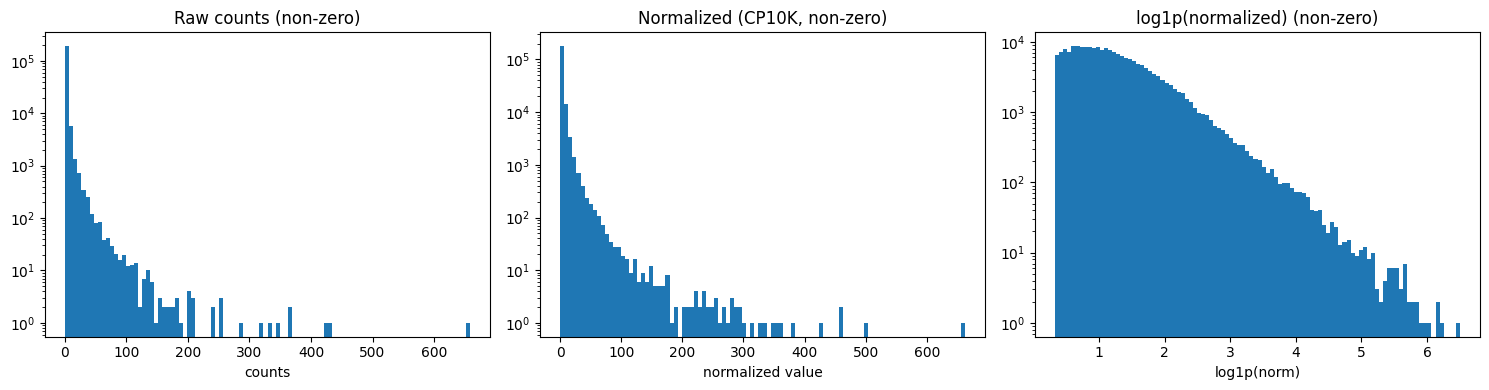

In [5]:
import scipy.sparse as sp
import matplotlib.pyplot as plt

def sample_nonzero(arr, max_n=200000):
    if sp.issparse(arr):
        vals = arr.data
    else:
        vals = arr.flatten()
    vals = vals[vals > 0]
    if vals.size > max_n:
        idx = np.random.choice(vals.size, max_n, replace=False)
        vals = vals[idx]
    return vals

raw_vals = sample_nonzero(adata.raw.X)
log_vals = sample_nonzero(adata.X)
norm_vals = np.expm1(log_vals)  

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(raw_vals, bins=100)
plt.yscale("log")
plt.title("Raw counts (non-zero)")
plt.xlabel("counts")

plt.subplot(1,3,2)
plt.hist(norm_vals, bins=100)
plt.yscale("log")
plt.title("Normalized (CP10K, non-zero)")
plt.xlabel("normalized value")

plt.subplot(1,3,3)
plt.hist(log_vals, bins=100)
plt.yscale("log")
plt.title("log1p(normalized) (non-zero)")
plt.xlabel("log1p(norm)")

plt.tight_layout()
plt.show()

# lineage mclust

In [3]:
import os
import pandas as pd

resultdir = "/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/result/"
file_in = os.path.join(resultdir, "WangNature/slingshot/IN/IN_lineage_mclust.csv")
file_en = os.path.join(resultdir, "WangNature/slingshot/EN/EN_lineage_mclust.csv")

df_in = pd.read_csv(file_in, sep="\t")
df_en = pd.read_csv(file_en, sep="\t")

id_col = "ID"         
mclust_col = "mclust" 

ids_in = df_in[id_col].astype(str).values
ids_en = df_en[id_col].astype(str).values

adata_in = adata[adata.obs_names.isin(ids_in)].copy()
adata_en = adata[adata.obs_names.isin(ids_en)].copy()

df_in_indexed = df_in.set_index(id_col)
adata_in.obs[mclust_col] = df_in_indexed.loc[adata_in.obs_names, mclust_col].values

df_en_indexed = df_en.set_index(id_col)
adata_en.obs[mclust_col] = df_en_indexed.loc[adata_en.obs_names, mclust_col].values

# pseudotime bin

In [7]:
import scanpy as sc
from anndata import read_h5ad
import pandas as pd
import numpy as np
import os
from os.path import join
import time
import argparse
import matplotlib.pyplot as plt
from scipy import sparse

adata_en = read_h5ad('/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025/obj_rna_raw_EN_slingshot.h5ad')
adata_in = read_h5ad('/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025/obj_rna_raw_IN_slingshot.h5ad')

resultdir = "/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/result/"
file_in = os.path.join(resultdir, "WangNature/slingshot/IN/IN_lineage_slingshot_results.csv")
file_en = os.path.join(resultdir, "WangNature/slingshot/EN/EN_lineage_slingshot_results.csv")

df_in = pd.read_csv(file_in)
df_en = pd.read_csv(file_en)

id_col = "ID"         
pseudotime_col = "average_pseudotime" 

df_in_indexed = df_in.set_index(id_col)
adata_in.obs[pseudotime_col] = df_in_indexed.loc[adata_in.obs_names, pseudotime_col].values

df_en_indexed = df_en.set_index(id_col)
adata_en.obs[pseudotime_col] = df_en_indexed.loc[adata_en.obs_names, pseudotime_col].values

adata_in.obs["pseudotime_bin20"] = pd.cut(adata_in.obs["average_pseudotime"],bins=20, labels=False)
adata_in.obs["pseudotime_bin50"] = pd.cut(adata_in.obs["average_pseudotime"],bins=50, labels=False)
adata_in.obs["pseudotime_bin100"] = pd.cut(adata_in.obs["average_pseudotime"],bins=100, labels=False)
adata_in.obs["pseudotime_bin200"] = pd.cut(adata_in.obs["average_pseudotime"],bins=200, labels=False)

adata_en.obs["pseudotime_bin20"] = pd.cut(adata_en.obs["average_pseudotime"],bins=20, labels=False)
adata_en.obs["pseudotime_bin50"] = pd.cut(adata_en.obs["average_pseudotime"],bins=50, labels=False)
adata_en.obs["pseudotime_bin100"] = pd.cut(adata_en.obs["average_pseudotime"],bins=100, labels=False)
adata_en.obs["pseudotime_bin200"] = pd.cut(adata_en.obs["average_pseudotime"],bins=200, labels=False)

In [8]:
import numpy as np

pt_in = adata_in.obs["average_pseudotime"]
pt_en = adata_en.obs["average_pseudotime"]

edges_in_20  = np.linspace(pt_in.min(), pt_in.max(), 21)
edges_in_50  = np.linspace(pt_in.min(), pt_in.max(), 51)
edges_in_100 = np.linspace(pt_in.min(), pt_in.max(), 101)
edges_in_200 = np.linspace(pt_in.min(), pt_in.max(), 201)

edges_en_20  = np.linspace(pt_en.min(), pt_en.max(), 21)
edges_en_50  = np.linspace(pt_en.min(), pt_en.max(), 51)
edges_en_100 = np.linspace(pt_en.min(), pt_en.max(), 101)
edges_en_200 = np.linspace(pt_en.min(), pt_en.max(), 201)

outdir = "/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/result/WangNature/slingshot/"

# IN
np.savetxt(f"{outdir}/IN/IN_pseudotime_edges_20.txt",  edges_in_20,  fmt="%.10f")
np.savetxt(f"{outdir}/IN/IN_pseudotime_edges_50.txt",  edges_in_50,  fmt="%.10f")
np.savetxt(f"{outdir}/IN/IN_pseudotime_edges_100.txt", edges_in_100, fmt="%.10f")
np.savetxt(f"{outdir}/IN/IN_pseudotime_edges_200.txt", edges_in_200, fmt="%.10f")

# EN
np.savetxt(f"{outdir}/EN/EN_pseudotime_edges_20.txt",  edges_en_20,  fmt="%.10f")
np.savetxt(f"{outdir}/EN/EN_pseudotime_edges_50.txt",  edges_en_50,  fmt="%.10f")
np.savetxt(f"{outdir}/EN/EN_pseudotime_edges_100.txt", edges_en_100, fmt="%.10f")
np.savetxt(f"{outdir}/EN/EN_pseudotime_edges_200.txt", edges_en_200, fmt="%.10f")

# mclust_Group

In [ ]:
adata_en.obs["mclust_Group"] = (
    adata_en.obs["mclust"].astype(str)
    + "_"
    + adata_en.obs["Group"].astype(str)
)
adata_in.obs["mclust_Group"] = (
    adata_in.obs["mclust"].astype(str)
    + "_"
    + adata_in.obs["Group"].astype(str)
)

# mclust_Group_region

In [ ]:
EN_CLUSTER_MERGE = {"ENlineage_2": "ENlineage_27", "ENlineage_7": "ENlineage_27"}

mclust_str = adata_en.obs["mclust"].astype(str)
n_merged = mclust_str.isin(EN_CLUSTER_MERGE.keys()).sum()
adata_en.obs["mclust"] = mclust_str.replace(EN_CLUSTER_MERGE)
print(f"Merged {n_merged} EN-L4-IT + EN-L4-IT-V1 cells into new cluster 'ENlineage_27' ({EN_CLUSTER_MERGE})")

adata_en.obs["mclust_Group_region"] = (
    adata_en.obs["mclust"].astype(str)
    + "_"
    + adata_en.obs["Group"].astype(str)
    + "_"
    + adata_en.obs["region_summary"].astype(str)
)
adata_in.obs["mclust_Group_region"] = (
    adata_in.obs["mclust"].astype(str)
    + "_"
    + adata_in.obs["Group"].astype(str)
    + "_"
    + adata_in.obs["region_summary"].astype(str)
)

print(adata_en.obs["mclust_Group_region"].nunique(), "unique EN mclust_Group_region groups")
print(adata_in.obs["mclust_Group_region"].nunique(), "unique IN mclust_Group_region groups")

pd.set_option("display.max_rows", None)

print("\nEN mclust_Group_region group sizes:")
print(adata_en.obs["mclust_Group_region"].value_counts())

print("\nIN mclust_Group_region group sizes:")
print(adata_in.obs["mclust_Group_region"].value_counts())

In [ ]:
adata_en.write_h5ad('/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025/obj_rna_raw_EN_slingshot.h5ad')
adata_in.write_h5ad('/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025/obj_rna_raw_IN_slingshot.h5ad')

# mclust_Group_region, paired-donor cohort only

In [ ]:
# restrict the mclust_Group_region group-level analysis to the SAME fixed
# 11-donor paired cohort instead of pooling all donors. ARKFrozen-18/-19 both being donor ARK14, not two different donors.
DATASET_TO_DONOR = {
    "ARKFrozen-1-PFC": "ARK1", "ARKFrozen-18-PFC": "ARK14", "ARKFrozen-19-V1": "ARK14",
    "ARKFrozen-20-CTX": "ARK15", "ARKFrozen-32-V1": "ARK25", "ARKFrozen-37-CTX": "ARK28",
    "ARKFrozen-41-PFC-2": "ARK31", "ARKFrozen-41-V1": "ARK31", "ARKFrozen-43-PFC": "ARK33",
    "ARKFrozen-45-CTX": "ARK35", "ARKFrozen-8-V1": "ARK5", "GW27-2-7-18-PFC": "GW27-2-7-18",
    "HDBR-14584-CTX": "HDBR-14584", "HDBR-14831-CTX": "HDBR-14831", "HDBR-14834-TC": "HDBR-14834",
    "HDBR-15020-FB": "HDBR-15020",
    "NIH-1325-BA10-2": "NIH-1325", "NIH-1325-BA17": "NIH-1325",
    "NIH-1671-BA10-2": "NIH-1671", "NIH-1671-BA17": "NIH-1671",
    "NIH-4267-BA10-2": "NIH-4267",
    "NIH-4341-BA17": "NIH-4341", "NIH-4341-BA9": "NIH-4341",
    "NIH-4373-BA17": "NIH-4373", "NIH-4373-BA9-3": "NIH-4373",
    "NIH-4392-BA17": "NIH-4392", "NIH-4392-BA9": "NIH-4392",
    "NIH-4458-BA9-3": "NIH-4458", "NIH-4458-BA17": "NIH-4458",
    "NIH-5162-BA17": "NIH-5162", "NIH-5162-BA9": "NIH-5162",
    "NIH-5376-BA17": "NIH-5376", "NIH-5376-BA9": "NIH-5376",
    "NIH-5554-BA17": "NIH-5554", "NIH-5554-BA9": "NIH-5554",
    "NIH-5900-BA17": "NIH-5900",
    "NIH-M1154-BA10-2": "NIH-M1154", "NIH-M2837-BA10-2": "NIH-M2837",
}
PAIRED_DONORS = ["ARK14", "ARK31", "NIH-1325", "NIH-1671", "NIH-4341",
                 "NIH-4373", "NIH-4392", "NIH-4458", "NIH-5162",
                 "NIH-5376", "NIH-5554"]

def filter_to_paired_donors(adata_lineage, lineage_name):
    assert "dataset" in adata_lineage.obs.columns, (
        f"{lineage_name} object is missing 'dataset' in .obs -- needed to resolve donor "
        f"identity via the audited DATASET_TO_DONOR mapping."
    )
    donor = adata_lineage.obs["dataset"].astype(str).map(DATASET_TO_DONOR)
    n_unmapped = donor.isna().sum()
    if n_unmapped > 0:
        print(f"[{lineage_name}] WARNING: {n_unmapped} cells have a 'dataset' value not in "
              f"DATASET_TO_DONOR -- excluded (treated as not paired).")
    keep = donor.isin(PAIRED_DONORS)
    out = adata_lineage[keep].copy()
    print(f"[{lineage_name}] Kept {out.n_obs} / {adata_lineage.n_obs} cells "
          f"({donor[keep].nunique()} paired donors present)")
    return out

adata_en_paired = filter_to_paired_donors(adata_en, "EN")
adata_in_paired = filter_to_paired_donors(adata_in, "IN")

DATA_PATH = "/mnt/isilon/gandal_lab/liaoyd/project/asd_rarevar_anno/data/SnMultiome_Wang2025"
adata_en_paired.write_h5ad(f"{DATA_PATH}/obj_rna_raw_EN_slingshot_paired.h5ad")
adata_in_paired.write_h5ad(f"{DATA_PATH}/obj_rna_raw_IN_slingshot_paired.h5ad")
print("Saved obj_rna_raw_EN_slingshot_paired.h5ad and obj_rna_raw_IN_slingshot_paired.h5ad")

# subclass_donor_region (per-donor EN/IN pooled across all types/ages, paired cohort)

In [ ]:
# Per-DONOR group-level Z-score, pooling ALL excitatory neurons (and
# separately ALL inhibitory neurons) across every type and every age Group, for PFC and
# V1 separately -- i.e. group key = (broad subclass) x donor x region, restricted to the
# same 11-donor paired cohort. Excitatory = Glutamatergic neuron + IPC-EN; Inhibitory = GABAergic neuron.
assert "subclass" in adata.obs.columns, "adata.obs is missing 'subclass'."

EN_SUBCLASSES = ["Glutamatergic neuron", "IPC-EN"]
IN_SUBCLASSES = ["GABAergic neuron"]

def EN_IN_FROM_SUBCLASS(subclass_series):
    s = subclass_series.astype(str)
    return np.select([s.isin(EN_SUBCLASSES), s.isin(IN_SUBCLASSES)], ["EN", "IN"], default=np.nan)

adata.obs["subclass_group"] = EN_IN_FROM_SUBCLASS(adata.obs["subclass"])
print("subclass -> subclass_group mapping (verify this looks right):")
print(adata.obs.groupby("subclass", observed=True)["subclass_group"].first().to_string())
print("\nsubclass_group counts:")
print(adata.obs["subclass_group"].value_counts(dropna=False))

assert "dataset" in adata.obs.columns, "adata.obs is missing 'dataset'."
adata.obs["donor"] = adata.obs["dataset"].astype(str).map(DATASET_TO_DONOR)

keep = adata.obs["donor"].isin(PAIRED_DONORS) & adata.obs["subclass_group"].isin(["EN", "IN"])
adata_subclass_paired = adata[keep].copy()
print(f"\nKept {adata_subclass_paired.n_obs} / {adata.n_obs} cells "
      f"({adata_subclass_paired.obs['donor'].nunique()} paired donors, EN+IN only)")

adata_subclass_paired.obs["subclass_donor_region"] = (
    adata_subclass_paired.obs["subclass_group"].astype(str)
    + "_"
    + adata_subclass_paired.obs["donor"].astype(str)
    + "_"
    + adata_subclass_paired.obs["region_summary"].astype(str)
)

pd.set_option("display.max_rows", None)
print("\nsubclass_donor_region group sizes:")
print(adata_subclass_paired.obs["subclass_donor_region"].value_counts())

adata_subclass_paired.write_h5ad(f"{DATA_PATH}/obj_rna_raw_subclass_donor_region_paired.h5ad")
print(f"\nSaved: {DATA_PATH}/obj_rna_raw_subclass_donor_region_paired.h5ad")